# Dataset 2

- Please extract data.zip into the directory "data"

In [1]:
# data_option = "dataset1"
data_option = "dataset2"

## Initial setup

In [2]:
from speciesot import configure_platform, Config, Data, SpeciesOT

In [3]:
configure_platform()  # For macOS with Apple Silicon
# configure_platform("gpu")  # For Linux or WSL2 with an NVIDIA GPU
# configure_platform("cpu")  # For other platforms

JAX is configured to use: METAL


### Computational parameters

In [4]:
if data_option == "dataset1":
    mask_option = "time_series_data"
    threshold = 3.0
    threshold_surer = 3.5
    high_epsilon = 0.01

elif data_option == "dataset2":
    mask_option = "one_time_point_data"
    threshold = 1.4
    threshold_surer = 2.5
    high_epsilon = 0.1

In [5]:
iterations = 1000
threshold_eps = 1e-4
low_epsilon = 0.0
threshold_tol = 3.0

In [6]:
if data_option == "dataset1":
    species = ["human", "macaque", "mouse"]
    species_pairs = []
    species_labels = ["Human", "Macaque", "Mouse"]

elif data_option == "dataset2":
    species = ["human", "chimpanzee", "gorilla", "orangutan", "macaque", "mouse"]
    species_pairs = []
    species_labels = [
        "Human_iPSC(AK02)",
        "Chimp_iPSC(AK02)",
        "Gorilla_iPSC(AITS)",
        "Orang_iPSC(AITS)",
        "Macaque_ESC(AITS)",
        "Mouse_EpiLC",
    ]

## Initialize the Config() class

In [7]:
if data_option == "dataset1":
    config = Config(
        "dataset1",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",  # "min" for exploring minimum converging varepsilon_min
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )

elif data_option == "dataset2":
    config = Config(
        "dataset2",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",  # "min" for exploring minimum converging varepsilon_min
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )

## Initialize the Data() class

In [8]:
data = Data(config)

### Read CSV file

In [9]:
data = data.read_csv()

### Geometrization steps (noise reduction and total count normalization)

In [10]:
data = data.normalization()

start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(16535), '#non-significant genes': np.int64(15612), '#silent genes': np.int64(0), 'ell': np.int64(65), 'Elapsed time': '0h 0m 8s 162ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15569), '#non-significant genes': np.int64(12952), '#silent genes': np.int64(0), 'ell': np.int64(32), 'Elapsed time': '0h 0m 1s 708ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15118), '#non-significant genes': np.int64(14736), '#silent genes': np.int64(0), 'ell': np.int64(66), 'Elapsed time': '0h 0m 10s 766ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(14588), '#non-significant genes': np.int64(14096), '#silent genes': np.int64(

### Geometrization step (gene selection using human transcription factors)

In [11]:
data = data.read_tf()

## Initialize the SpeciesOT() class

In [12]:
spe_ot = SpeciesOT(data)

### Geometrization step (filtering)

In [13]:
spe_ot = spe_ot.preprocessing()

### Geometrization step (distance matrix computation)

In [14]:
spe_ot = spe_ot.calculate_gene_distance_matrix()

### Entropically regularized Gromov-Wasserstein optimal transport

In [15]:
spe_ot = spe_ot.gromov_wasserstein_ot()

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1762787318.943704 2416463 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1762787318.954833 2416463 service.cc:145] XLA service 0x35624e1b0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762787318.954851 2416463 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1762787318.956100 2416463 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1762787318.956111 2416463 mps_client.cc:384] XLA backend will use up to 103078739968 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M3 Max

systemMemory: 128.00 GB
maxCacheSize: 48.00 GB

epsilon = 0.1000000 converged


### Normalized optimal transport plan

In [16]:
spe_ot = spe_ot.normalize_otp()

### Transcriptomic discrepancy

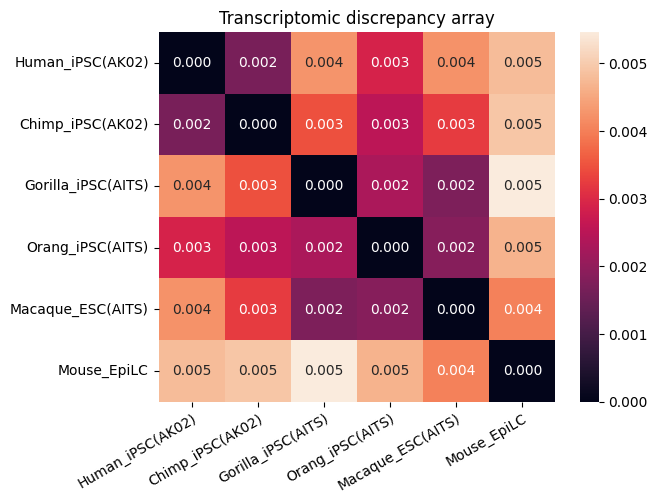

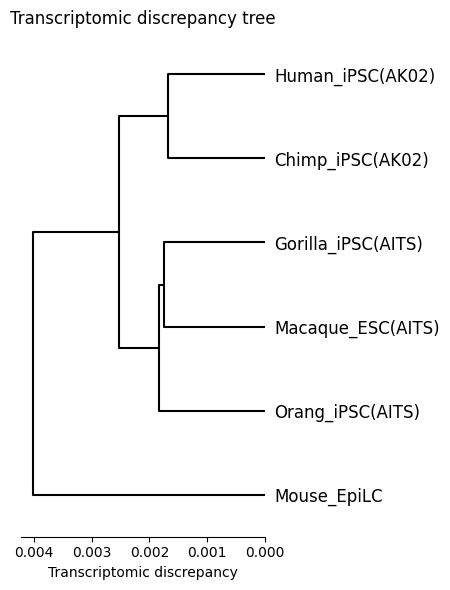

In [17]:
spe_ot.plot_transcriptomic_discrepancy()

## Chained Processing

In [18]:
data2 = Data(config).read_csv().normalization().read_tf()

start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(16535), '#non-significant genes': np.int64(15612), '#silent genes': np.int64(0), 'ell': np.int64(65), 'Elapsed time': '0h 0m 8s 811ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15569), '#non-significant genes': np.int64(12952), '#silent genes': np.int64(0), 'ell': np.int64(32), 'Elapsed time': '0h 0m 1s 944ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15118), '#non-significant genes': np.int64(14736), '#silent genes': np.int64(0), 'ell': np.int64(66), 'Elapsed time': '0h 0m 12s 065ms', 'solver': 'full'}
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(14588), '#non-significant genes': np.int64(14096), '#silent genes': np.int64(

epsilon = 0.1000000 converged


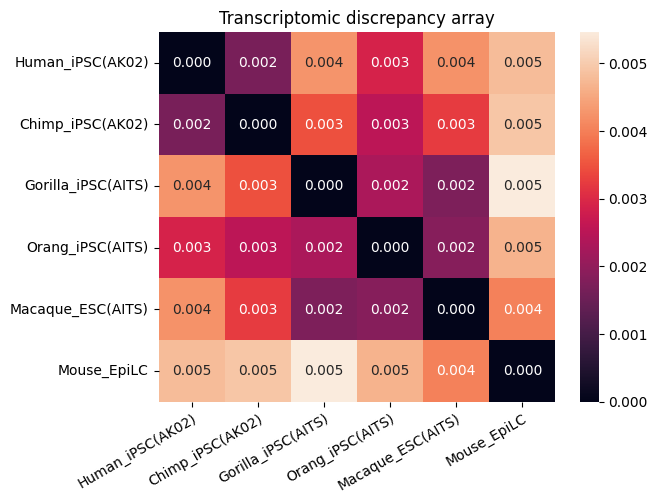

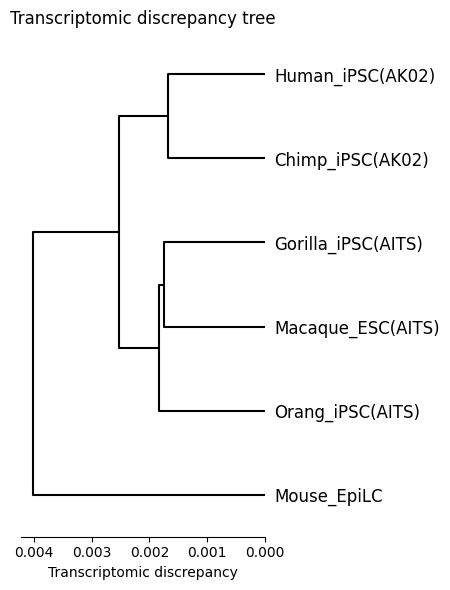

In [19]:
spe_ot2 = (
    SpeciesOT(data2)
    .preprocessing()
    .calculate_gene_distance_matrix()
    .gromov_wasserstein_ot()
    .normalize_otp()
    .plot_transcriptomic_discrepancy()
)

## Differential expression analysis and selection of Wnt-related genes

### Discover genes differentially expressed between the AK02 and AITS culture conditions

In [20]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Group by condition
spe_to_condition = {
    spe_ot.species[0]: "AK02",
    spe_ot.species[1]: "AK02",
    spe_ot.species[2]: "AITS",
    spe_ot.species[3]: "AITS",
    spe_ot.species[4]: "AITS",
    spe_ot.species[5]: "neither",  # excluded
}

condition_to_dfs = {"AK02": [], "AITS": []}
for spe, df in spe_ot.plot_normalized_log_select_preprocessed_masked.items():
    cond = spe_to_condition.get(spe)
    if cond in condition_to_dfs:
        condition_to_dfs[cond].append(df)

if not condition_to_dfs["AK02"] or not condition_to_dfs["AITS"]:
    raise ValueError("Missing data for one or both conditions.")

# Concatenate and align
ak02_df = pd.concat(condition_to_dfs["AK02"])
aits_df = pd.concat(condition_to_dfs["AITS"])
common_genes = ak02_df.columns.intersection(aits_df.columns)
ak02_df, aits_df = ak02_df[common_genes], aits_df[common_genes]

# Statistics
pvals, log2fc = [], []
for g in common_genes:
    x, y = ak02_df[g].dropna(), aits_df[g].dropna()
    _, p = ttest_ind(x, y, equal_var=False)
    pvals.append(p)
    log2fc.append(np.log2(x.mean() + 1e-6) - np.log2(y.mean() + 1e-6))

# Multiple testing
padj = multipletests(pvals, method="fdr_bh")[1]

# Results
results_df = pd.DataFrame(
    {"gene": common_genes, "log2FC": log2fc, "pval": pvals, "padj": padj}
)

# Significant genes
sig = results_df.query("padj < 0.05 and abs(log2FC) > 1").sort_values("padj")
genes_AK02 = sig.query("log2FC > 1")["gene"].tolist()
genes_AITS = sig.query("log2FC < -1")["gene"].tolist()

display(results_df.head())
print("Genes higher in AK02:", genes_AK02)
print("Genes higher in AITS:", genes_AITS)

,gene,log2FC,pval,padj
0,ADNP,0.044285,7.651345e-38,9.175330e-38
1,ADNP2,0.043396,9.499142e-47,1.164218e-46
2,AEBP1,-0.362036,0.000000e+00,0.000000e+00
3,AEBP2,0.076010,3.565237e-33,4.227611e-33
4,AHCTF1,-0.230504,3.236920e-277,5.916623e-277


Genes higher in AK02: ['TCFL5', 'ZBTB37', 'ZBTB47', 'ZBTB8B', 'ZFP14', 'ZMAT4', 'ZNF138', 'ZNF165', 'ZNF202', 'ZNF25', 'ZNF251', 'ZBTB22', 'ZBTB20', 'ZBTB12', 'ZSCAN9', 'SNAI1', 'SOX21', 'SOX9', 'SP110', 'SREBF1', 'ZNF316', 'STAT6', 'ZXDC', 'TEF', 'TFEB', 'THAP8', 'TP73', 'TSHZ2', 'TSHZ3', 'ZNF333', 'ZNF337', 'ZNF692', 'ZNF71', 'ZNF726', 'ZNF764', 'ZNF771', 'ZNF778', 'ZNF688', 'ZNF784', 'ZNF793', 'ZNF823', 'ZSCAN30', 'ZNF844', 'ZNF880', 'ZNF883', 'ZNF786', 'ZNF599', 'ZNF589', 'ZNF385A', 'ZNF385B', 'ZNF397', 'ZNF417', 'ZNF449', 'ZSCAN31', 'ZNF500', 'ZNF514', 'ZNF524', 'ZNF546', 'ZNF563', 'ZNF573', 'ZNF585A', 'ZNF519', 'SIX3', 'SOX15', 'RORB', 'FBXL19', 'FEZF1', 'FOXI3', 'HIF3A', 'IRF2', 'IRF7', 'EMX1', 'ARNTL', 'BATF2', 'BCL6B', 'CASZ1', 'CC2D1A', 'CCDC17', 'CENPBD1', 'CSRNP3', 'CXXC4', 'DBP', 'DEAF1', 'ELF1', 'ELF3', 'ZNF891', 'NOTO', 'NR1D2', 'NR1H3', 'KLF15', 'POU3F1', 'POU5F2', 'PPARA', 'PURG', 'RARG', 'RORA', 'PBX2', 'NHLH1', 'NFATC4', 'LHX1', 'MAF', 'L3MBTL4', 'ZFP2', 'MLXIPL', 'M

### Expression levels of Wnt-related genes

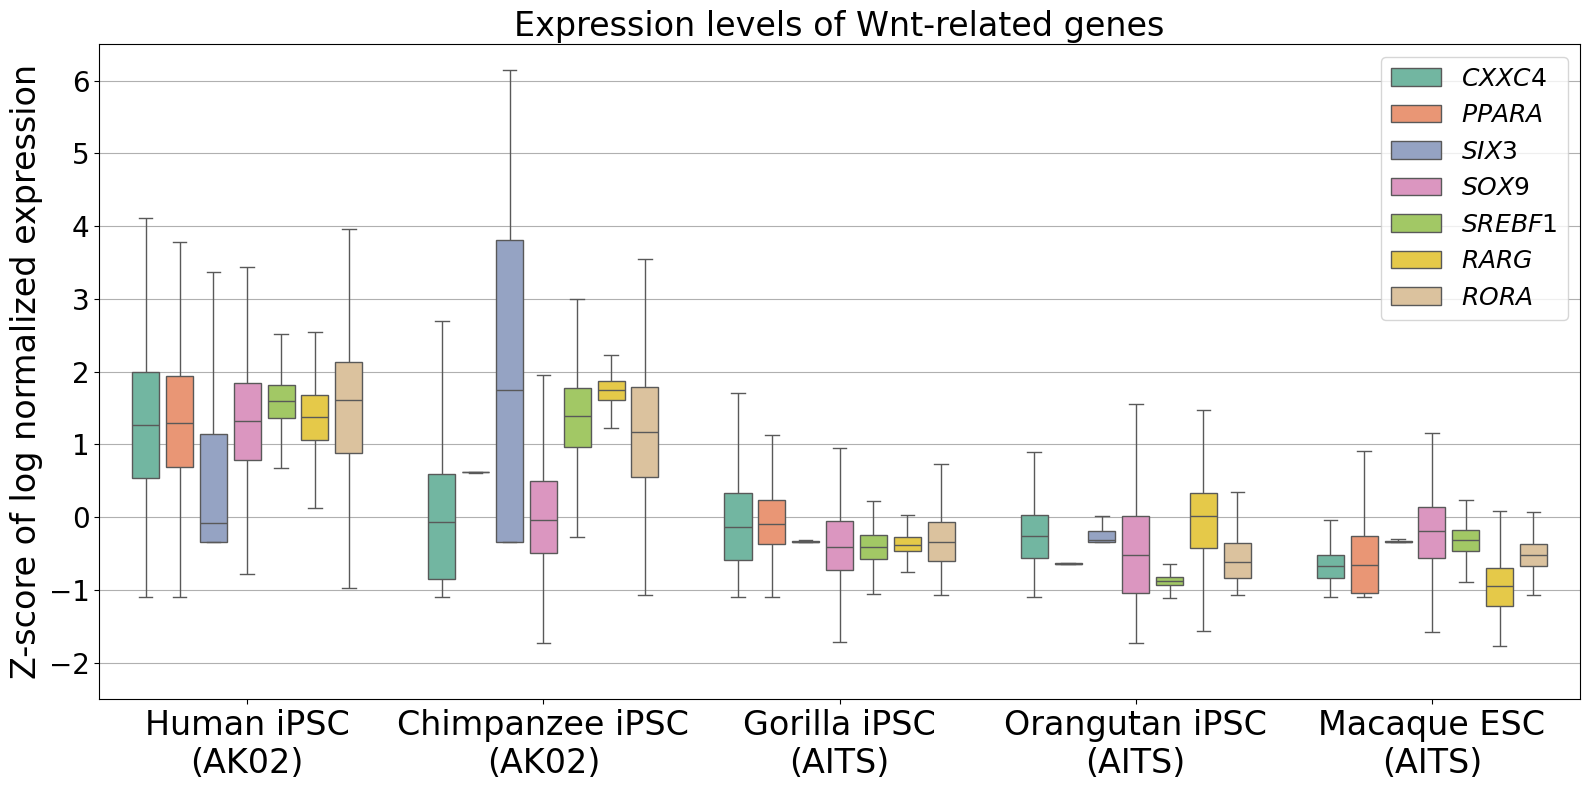

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

marker_genes = [
    "CXXC4",
    "PPARA",
    "SIX3",
    "SOX9",
    "SREBF1",
    "RARG",
    "RORA",
]

labels = [
    "Human iPSC\n(AK02)",
    "Chimpanzee iPSC\n(AK02)",
    "Gorilla iPSC\n(AITS)",
    "Orangutan iPSC\n(AITS)",
    "Macaque ESC\n(AITS)",
    "Mouse EpiLC",
]

# Flatten
data = []
for spe in spe_ot.species[:-1]:
    for g in marker_genes:
        if g in spe_ot.plot_normalized_log[spe]:
            for v in spe_ot.plot_normalized_log[spe][g]:
                data.append({"Gene": g, "Species": spe, "Expression": v})
df = pd.DataFrame(data)

# Z-score
df["Expression"] = df.groupby("Gene")["Expression"].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)
df["Gene"] = df["Gene"].str.upper().apply(lambda g: f"$\\it{{{g}}}$")

# Plot
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df,
    x="Species",
    y="Expression",
    hue="Gene",
    palette="Set2",
    showcaps=True,
    showfliers=False,
    gap=0.2,
)
ax = plt.gca()
ax.legend(fontsize=18)
ax.set_xticks(range(len(labels[:-1])))
ax.set_xticklabels(labels[:-1], fontsize=24)
ax.tick_params(axis="y", labelsize=20)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
plt.title("Expression levels of Wnt-related genes", fontsize=24)
plt.ylabel("Z-score of log normalized expression", fontsize=24)
plt.ylim(-2.5, 6.5)
plt.xlabel("")
plt.tight_layout()
plt.show()

## End of tutorial